# Plot results

## Setup

In [1]:
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np

## H chains (Fig. 2)

In [2]:
natoms = np.loadtxt("./data/natoms.txt")
nqubits = 2 * natoms

runtime = np.loadtxt("./data/runtime_lowdin.txt")
runtime_burton = np.loadtxt("./data/runtime_burton.txt")

gates_twoq = np.loadtxt("./data/twoq_gates.txt")
gates_total = np.loadtxt("./data/total_gates.txt")

energies_ucj = np.loadtxt("./data/energies_lowdin.txt")
energies_ucj_burton = np.loadtxt("./data/all_energies_ucj_hchains_burton.txt")
energies_hf = np.loadtxt("./data/energies_hf.txt")
energies_ccsd = np.loadtxt("./data/energies_ccsd.txt")

n_opt = np.loadtxt("./data/n_opt.txt")
ucj_opt = np.loadtxt("./data/ucj_opt.txt")

In [3]:
assert np.allclose(energies_ucj, energies_ucj_burton)

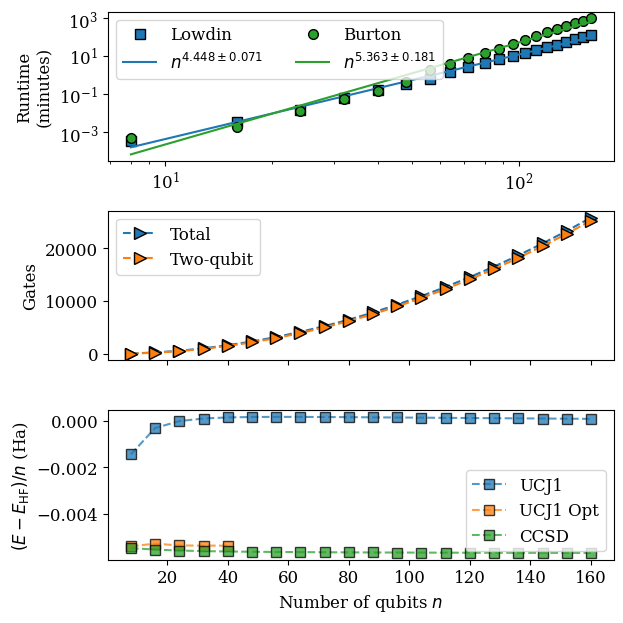

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(6.4, 6.4), gridspec_kw={"height_ratios": [1, 1, 1]}
)

# --- Panel 1 (top): runtime with power-law fit, log-log ---
(m, b), cov = np.polyfit(np.log(nqubits), np.log(runtime / 60), deg=1, cov=True)
se = np.sqrt(cov[0, 0])
fit = np.exp(b) * nqubits**m

ax1.loglog(nqubits, runtime / 60, "s", ms=7, label="Lowdin", color="tab:blue", mec="black")
ax1.loglog(nqubits, fit, label=fr"$n^{{{m:.3f} \pm {se:.3f}}}$", color="tab:blue")
# ax1.set_xlabel("Number of qubits $n$")


(m_b, b_b), cov_b = np.polyfit(np.log(nqubits), np.log(runtime_burton / 60), deg=1, cov=True)
se_b = np.sqrt(cov_b[0, 0])
ax1.loglog(nqubits, runtime_burton / 60, "o", ms=7, color="tab:green", mec="black",
           label="Burton")
ax1.loglog(nqubits, np.exp(b_b) * nqubits**m_b, "-",  label=fr"$n^{{{m_b:.3f} \pm {se_b:.3f}}}$", color="tab:green")

ax1.set_ylabel("Runtime\n(minutes)")
ax1.legend(ncol=2)

# --- Panels 2 and 3 share a linear x-axis ---
ax3.sharex(ax2)

# --- Panel 2: gate counts ---
ax2.plot(nqubits, gates_total, "-->", mec="black", ms=9, label="Total")
ax2.plot(nqubits, gates_twoq, "-->", ms=9, mec="black", label="Two-qubit")
ax2.set_ylabel("Gates")
ax2.legend()
ax2.tick_params(labelbottom=False)      # hide duplicate tick labels

# --- Panel 3: normalized correlation energies ---
ax3.plot(nqubits, (energies_ucj - energies_hf) / nqubits, "--s", mec="black", ms=7,
         alpha=0.75, label="UCJ1")
ax3.plot(n_opt, (ucj_opt - energies_hf[:len(n_opt)]) / n_opt, "--s", mec="black", ms=7,
         alpha=0.75, label="UCJ1 Opt")
ax3.plot(nqubits, (energies_ccsd - energies_hf) / nqubits, "--s", mec="black", ms=7,
         alpha=0.75, label="CCSD")
# ax3.plot(n_opt, ())
ax3.set_xlabel("Number of qubits $n$")
ax3.set_ylabel(r"$(E - E_{\text{HF}}) / n$ (Ha)")
ax3.legend()

plt.tight_layout()

## Appendix H algorithm for H2 (Fig. 3)

In [5]:
filename = "./data/appendix_h_cumulative_H2.npz"
data = np.load(filename)

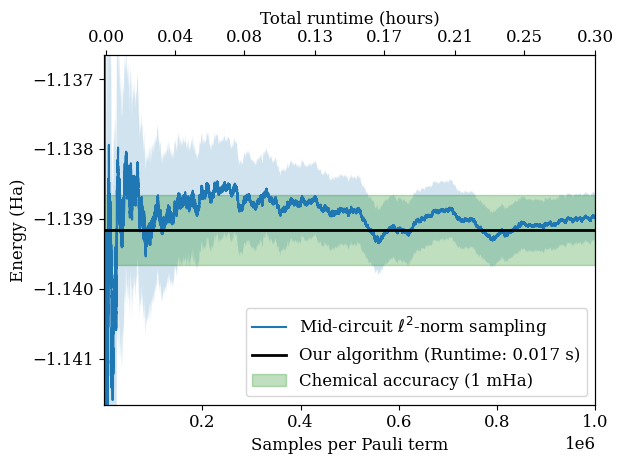

In [6]:
sample_number = data["sample_counts"]
appendix_h_energy = data["energy"]
appendix_h_sem = data["stderr"]

runtime_sample_number = data["runtime_sample_counts"]
cumulative_runtime_sec = data["runtime_seconds"]

# Exact reference energy saved by the cumulative script.
our_energy = float(data["E_burton"])

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots()

# Appendix H cumulative energy estimate
ax.plot(
    sample_number,
    appendix_h_energy,
    lw=1.5,
    label=r"Mid-circuit $\ell^2$-norm sampling",
)

# +/- 1 standard error, computed directly by the Appendix H run
valid = np.isfinite(appendix_h_sem)

ax.fill_between(
    sample_number[valid],
    appendix_h_energy[valid] - appendix_h_sem[valid],
    appendix_h_energy[valid] + appendix_h_sem[valid],
    alpha=0.20,
    # label=r"Appendix H $\pm 1$ SEM",
)

# Our algorithm energy
ax.axhline(
    our_energy,
    color="black",
    linestyle="-",
    lw=2,
    label=f"Our algorithm (Runtime: 0.017 s)",
)

# Chemical-accuracy region: +/- 0.5 mHa gives a total width of 1 mHa
ax.axhspan(
    our_energy - 0.0005,
    our_energy + 0.0005,
    color="green",
    alpha=0.25,
    label="Chemical accuracy (1 mHa)",
)

ax.set_xlabel("Samples per Pauli term")
ax.set_ylabel("Energy (Ha)")
ax.set_xlim(1, sample_number[-1])

# ------------------------------------------------------------------
# Top horizontal axis: cumulative Appendix H runtime
# ------------------------------------------------------------------

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

# Use the actual runtime checkpoints saved by the cumulative script.
n_top_ticks = 8

tick_indices = np.linspace(
    0,
    len(runtime_sample_number) - 1,
    min(n_top_ticks, len(runtime_sample_number)),
    dtype=int,
)

tick_samples = runtime_sample_number[tick_indices]
tick_runtime_hours = cumulative_runtime_sec[tick_indices] / 3600.0

ax_top.set_xticks(tick_samples)
ax_top.set_xticklabels(
    [f"{t:.2f}" for t in tick_runtime_hours]
)
ax_top.set_xlabel("Total runtime (hours)")


ax.legend()
ax.set_ylim(our_energy - 0.0025, our_energy + 0.0025)

plt.tight_layout()
plt.show()

## Appendix H algorithm for H10 (Fig. 4)

In [7]:
filename = "./data/appendix_h_cumulative_H10.npz"
data = np.load(filename)

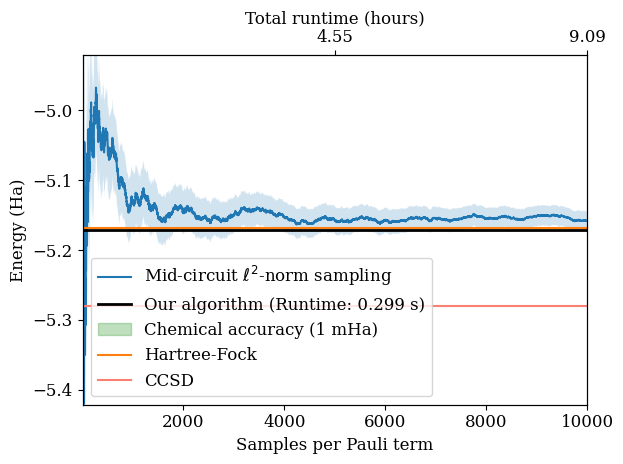

In [8]:
sample_number = data["sample_counts"]
appendix_h_energy = data["energy"]
appendix_h_sem = data["stderr"]

runtime_sample_number = data["runtime_sample_counts"]
cumulative_runtime_sec = data["runtime_seconds"]

# Exact reference energy saved by the cumulative script.
our_energy = float(data["E_burton"])

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots()

# Appendix H cumulative energy estimate
ax.plot(
    sample_number,
    appendix_h_energy,
    lw=1.5,
    label=r"Mid-circuit $\ell^2$-norm sampling",
)

# +/- 1 standard error, computed directly by the Appendix H run
valid = np.isfinite(appendix_h_sem)

ax.fill_between(
    sample_number[valid],
    appendix_h_energy[valid] - appendix_h_sem[valid],
    appendix_h_energy[valid] + appendix_h_sem[valid],
    alpha=0.20,
    # label=r"Appendix H $\pm 1$ SEM",
)

# Our algorithm energy
ax.axhline(
    our_energy,
    color="black",
    linestyle="-",
    lw=2,
    label=f"Our algorithm (Runtime: 0.299 s)",
)

# Chemical-accuracy region: +/- 0.5 mHa gives a total width of 1 mHa
ax.axhspan(
    our_energy - 0.0005,
    our_energy + 0.0005,
    color="green",
    alpha=0.25,
    label="Chemical accuracy (1 mHa)",
)

ax.axhline(
    -5.169095044466,
    label="Hartree-Fock",
    ls="-",
    color="tab:orange",
)
ax.axhline(
    -5.280732161596,
    label="CCSD",
    ls="-",
    color="salmon",
)

ax.set_xlabel("Samples per Pauli term")
ax.set_ylabel("Energy (Ha)")
ax.set_xlim(1, sample_number[-1])


# ------------------------------------------------------------------
# Top horizontal axis: cumulative Appendix H runtime
# ------------------------------------------------------------------

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

# Use the actual runtime checkpoints saved by the cumulative script.
n_top_ticks = 8

tick_indices = np.linspace(
    0,
    len(runtime_sample_number) - 1,
    min(n_top_ticks, len(runtime_sample_number)),
    dtype=int,
)

tick_samples = runtime_sample_number[tick_indices]
tick_runtime_hours = cumulative_runtime_sec[tick_indices] / 3600.0

ax_top.set_xticks(tick_samples)
ax_top.set_xticklabels(
    [f"{t:.2f}" for t in tick_runtime_hours]
)
ax_top.set_xlabel("Total runtime (hours)")


ax.legend()
ax.set_ylim(our_energy - 0.25, our_energy + 0.25)

plt.tight_layout()
plt.show()

## H chain optimization runtimes (Fig. 5)

In [9]:
n_qubits = [8, 16, 24, 32, 40]

energy_diff_per_qubit_Ha = [
    -0.0054028540,
    -0.0053829424,
    -0.0053809238,
    -0.0053841758,
    -0.0049587576,
]

n_parameters = [
    36,
    136,
    300,
    528,
    820,
]

n_iterations = [
    97,
    1138,
    1575,
    2194,
    3855,
]

n_function_evaluations = [
    114,
    1203,
    1654,
    2289,
    3994,
]

n_gradient_evaluations = [
    114,
    1203,
    1654,
    2289,
    3994,
]

ccsd_runtime_s = [
    0.0361,
    0.0513,
    0.1209,
    0.1655,
    0.1896,
]

optimization_runtime_mean_s = [
    5.9626,
    22.9370,
    50.4936,
    115.3953,
    574.9841,
]

optimization_runtime_sem_s = [
    0.1842,
    0.2073,
    0.1003,
    0.2664,
    0.2874,
]

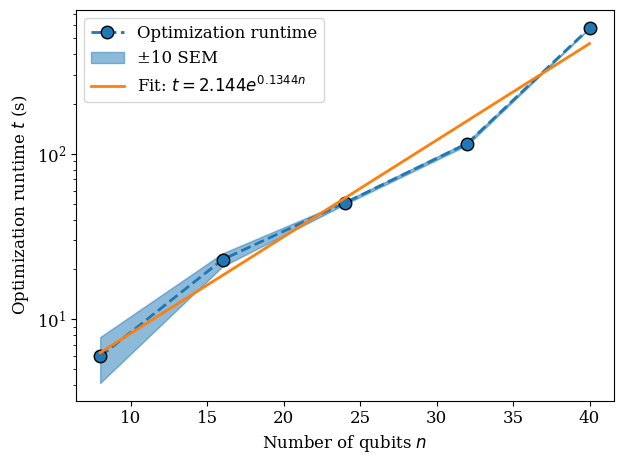

In [10]:
n_qubits = np.array(n_qubits)
runtime = np.array(optimization_runtime_mean_s)
sem = np.array(optimization_runtime_sem_s)

log_runtime = np.log(runtime)

B, log_A = np.polyfit(n_qubits, log_runtime, 1)
A = np.exp(log_A)

# Smooth fitted curve
n_fit = np.linspace(n_qubits.min(), n_qubits.max(), 500)
runtime_fit = A * np.exp(B * n_fit)

fig, ax = plt.subplots()
ax.plot(
    n_qubits,
    runtime,
    "--o",
    mec="black",
    linewidth=2,
    markersize=9,
    label="Optimization runtime",
)

# ±1 SEM shaded region
ax.fill_between(
    n_qubits,
    runtime - 10 * sem,
    runtime + 10 * sem,
    color="C0",
    alpha=0.50,
    label="±10 SEM",
)

# Exponential fit
ax.plot(
    n_fit,
    runtime_fit,
    "-",
    color="C1",
    linewidth=2,
    label=fr"Fit: $t={A:.3f}e^{{{B:.4f}n}}$",
)

# Log y-axis
ax.set_yscale("log")

ax.set_xlabel("Number of qubits $n$")
ax.set_ylabel("Optimization runtime $t$ (s)")
ax.legend()

plt.tight_layout()